In [34]:
# This is just for learning RDKit

from rdkit import Chem
mol = Chem.MolFromSmiles('CCO')

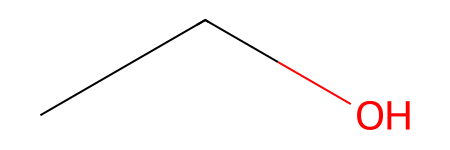

In [35]:
mol

In [36]:
# For error handling cases
bad = Chem.MolFromSmiles("Not a molecule")
print(bad)

None


[21:30:16] SMILES Parse Error: syntax error while parsing: Not
[21:30:16] SMILES Parse Error: check for mistakes around position 3:
[21:30:16] Not
[21:30:16] ~~^
[21:30:16] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'


In [37]:
mol.GetNumAtoms()        # 3 (for ethanol: C, C, O)
  # canonical SMILES, 'CCO'

3

In [38]:
mol.GetNumBonds()  

2

In [39]:
Chem.MolToSmiles(mol)

'CCO'

In [40]:
# Descriptors
from rdkit.Chem import Descriptors

Descriptors.MolWt(mol)

46.069

In [41]:
Descriptors.TPSA(mol)  # topological polar surface area

20.23

In [42]:
Descriptors.MolLogP(mol)

-0.0014000000000000123

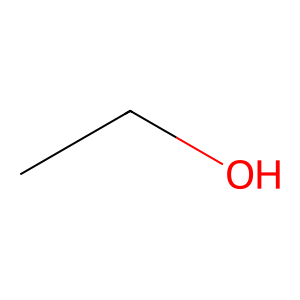

In [43]:
from rdkit.Chem import Draw

Draw.MolToImage(mol)

In [44]:
from rdkit.Chem import AllChem

fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

[21:30:17] DEPRECATION WARNING: please use MorganGenerator


In [45]:
from rdkit.Chem import rdFingerprintGenerator

generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fp = generator.GetFingerprint(mol)

In [46]:
fp

In [47]:
fp.ToBitString()

'000000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

In [48]:
list(fp.GetOnBits())

[80, 222, 294, 807, 1057, 1410]

In [49]:
fp.GetNumOnBits()

6

[21:30:17] DEPRECATION WARNING: please use MorganGenerator


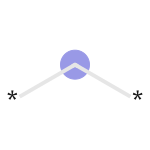

In [50]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

# Requires the *older* fingerprint call with bitInfo, since MorganGenerator
# handles this slightly differently
bit_info = {}
fp_old = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048, bitInfo=bit_info)

# Draw the substructure for one specific "on" bit
on_bits = list(fp_old.GetOnBits())
Draw.DrawMorganBit(mol, on_bits[0], bit_info)

In [51]:
molecules = {
    "Benzene": "c1ccccc1",
    "Toluene": "Cc1ccccc1",
    "Phenol": "Oc1ccccc1",
    "Aniline": "Nc1ccccc1",
    "Nitrobenzene": "[O-][N+](=O)c1ccccc1"
}

In [52]:
for key, index in molecules.items():
    print(index)

c1ccccc1
Cc1ccccc1
Oc1ccccc1
Nc1ccccc1
[O-][N+](=O)c1ccccc1


In [53]:
from rdkit import Chem
from rdkit.Chem import Descriptors
mole_dict = {}
for name, structure in molecules.items():
    mol=Chem.MolFromSmiles(structure)
    atom_num = mol.GetNumAtoms()
    bonds_num = mol.GetNumBonds()
    mol_wt = Descriptors.MolWt(mol) 
    tpsa = Descriptors.TPSA(mol)
    mol_logp = Descriptors.MolLogP(mol)
    mole_dict[name]= [atom_num, bonds_num, mol_wt,tpsa, mol_logp ]

print(mole_dict)    


{'Benzene': [6, 6, 78.11399999999999, 0.0, 1.6866], 'Toluene': [7, 7, 92.14099999999999, 0.0, 1.99502], 'Phenol': [7, 7, 94.11299999999999, 20.23, 1.3921999999999999], 'Aniline': [7, 7, 93.12899999999999, 26.02, 1.2688000000000001], 'Nitrobenzene': [9, 9, 123.11099999999996, 43.14, 1.5948]}


In [54]:
import pandas as pd
df = pd.DataFrame(mole_dict).T
df

,0,1,2,3,4
Benzene,6.0,6.0,78.114,0.00,1.68660
Toluene,7.0,7.0,92.141,0.00,1.99502
Phenol,7.0,7.0,94.113,20.23,1.39220
Aniline,7.0,7.0,93.129,26.02,1.26880
Nitrobenzene,9.0,9.0,123.111,43.14,1.59480


In [55]:
df.columns = ["atom_num", "bonds_num", "mol_wt", "tpsa","mol_logp"]

In [56]:
df

,atom_num,bonds_num,mol_wt,tpsa,mol_logp
Benzene,6.0,6.0,78.114,0.00,1.68660
Toluene,7.0,7.0,92.141,0.00,1.99502
Phenol,7.0,7.0,94.113,20.23,1.39220
Aniline,7.0,7.0,93.129,26.02,1.26880
Nitrobenzene,9.0,9.0,123.111,43.14,1.59480


In [61]:
df.index.name = 'molecule'

In [62]:
df

,atom_num,bonds_num,mol_wt,tpsa,mol_logp
molecule,,,,,
Benzene,6.0,6.0,78.114,0.00,1.68660
Toluene,7.0,7.0,92.141,0.00,1.99502
Phenol,7.0,7.0,94.113,20.23,1.39220
Aniline,7.0,7.0,93.129,26.02,1.26880
Nitrobenzene,9.0,9.0,123.111,43.14,1.59480


In [59]:
type(df.set_index)

method

In [60]:
type(df)

pandas.DataFrame